### Project Name -
# Analysis on Ford_Go_Bikes Sharing Data

*  Project Type - EDA
*  Contribution - Individual

# Problem Statement
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Ford GoBike bike-sharing dataset to understand user behavior, trip patterns, seasonal trends, and factors affecting trip duration.The insights will help improve bike availability, customer satisfaction,and operational efficiency.

# Project Summary



The rapid growth of urbanization has increased the demand for sustainable and efficient transportation systems. Bike-sharing services have emerged as an environmentally friendly and cost-effective mode of transportation, offering an alternative to conventional commuting methods. This project presents an Exploratory Data Analysis (EDA) of the Ford GoBike dataset with the objective of understanding rider behavior, identifying travel patterns, and generating actionable insights that can support operational and strategic decision-making.

The dataset consists of historical trip records containing information such as trip duration, start and end times, user type, gender, birth year, and station details. Since the data was collected across multiple monthly files, the first stage of the project involved consolidating these files into a single dataset. Data preprocessing was then performed to improve the quality and reliability of the analysis. This process included handling missing values, removing duplicate records, correcting inconsistent data types, and converting date and time attributes into a standardized datetime format. In addition, new variables such as trip duration in minutes, ride hour, day of the week, month, and year were derived to facilitate temporal analysis.

Following data preparation, descriptive statistical techniques were applied to understand the overall characteristics of the dataset. Measures of central tendency and dispersion were used to summarize numerical variables, while frequency distributions were examined for categorical features. Various visualization techniques, including histograms, bar charts, box plots, count plots, and heatmaps, were employed to identify trends, detect outliers, and examine relationships among different variables.

The exploratory analysis primarily focused on answering three important business questions. The first objective was to determine the average duration of bike trips, providing an overall understanding of user riding behavior. The second objective examined whether trip duration varied across different months and seasons, thereby identifying any temporal patterns in customer usage. The third objective investigated whether differences in trip duration were associated with user membership categories, specifically comparing Subscribers and Customers. These analyses provided valuable insights into how user characteristics and seasonal factors influence travel behavior.

The analysis also explored additional aspects of rider activity, including the distribution of trips across different hours of the day and days of the week. The findings highlighted variations in demand during peak commuting periods and differences in usage between weekdays and weekends. Demographic variables such as gender and age were also examined to better understand the composition of the user base. Correlation analysis was performed on numerical variables to identify potential relationships that could support further investigation.

Based on the results obtained through EDA, several practical recommendations were formulated. These include improving bike availability during periods of high demand, optimizing bike redistribution across popular stations, designing targeted promotional campaigns during periods of lower usage, and encouraging casual users to transition into subscription-based memberships. Such recommendations have the potential to improve customer satisfaction, increase operational efficiency, and enhance the overall effectiveness of the bike-sharing service.

In conclusion, this project demonstrates the importance of Exploratory Data Analysis as a foundational step in the data analytics process. By systematically cleaning, transforming, visualizing, and interpreting the data, meaningful insights were generated regarding customer behavior and system performance. The findings provide valuable information that can assist stakeholders in making informed business decisions while also establishing a strong analytical foundation for future predictive modeling and advanced data analytics applications.


# # Business Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on the Ford GoBike dataset to understand customer usage patterns and operational trends. The study aims to generate meaningful insights that support data-driven decision-making and improve the efficiency of the bike-sharing service.

The key objectives are:

* To determine the average trip duration of users.
* To analyze the effect of months and seasons on trip duration.
* To compare the riding behavior of Subscribers and Customers.
* To identify peak riding hours and days of the week.
* To examine customer demographics such as age and gender.
* To identify significant trends, patterns, and outliers in the dataset.
* To provide business recommendations for improving bike allocation, service quality, and customer satisfaction.


Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

Loading Dataset

In [2]:
# 1. Grab all 12 CSV files from your folder
csv_files = glob.glob("/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED")


In [3]:
print(csv_files)

['/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED']


In [4]:
folder_path = "/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED"

csv_files = glob.glob(folder_path + "/*.csv")

print(csv_files)

['/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201801-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201802-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201803-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201804-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201805-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201806-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201807-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201808-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201809-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201810-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBIKE UNZIPPED/201811-fordgobike-tripdata.csv', '/content/drive/MyDrive/Labmentix/FORDGOBI

In [5]:
df_list = [pd.read_csv(file) for file in csv_files]

In [6]:
csv_files = glob.glob(folder_path + "/**/*.csv", recursive=True)

df_list = [pd.read_csv(file) for file in csv_files]

In [7]:
# 3. Concatenate all DataFrames into one master DataFrame
combined_df = pd.concat(df_list, ignore_index=True)

In [8]:
# 4. Save your single, unified file
combined_df.to_csv("combined_output.csv", index=False)

In [9]:
df = combined_df.copy()

In [10]:
df = pd.read_csv("combined_output.csv")

Data Understanding and Exploration

In [11]:
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,75284,2018-01-31 22:52:35.2390,2018-02-01 19:47:19.8240,120.0,Mission Dolores Park,37.761420,-122.426435,285.0,Webster St at O'Farrell St,37.783521,-122.431158,2765,Subscriber,1986.0,Male,No
1,85422,2018-01-31 16:13:34.3510,2018-02-01 15:57:17.3100,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,15.0,San Francisco Ferry Building (Harry Bridges Pl...,37.795392,-122.394203,2815,Customer,NaN,NaN,No
2,71576,2018-01-31 14:23:55.8890,2018-02-01 10:16:52.1160,304.0,Jackson St at 5th St,37.348759,-121.894798,296.0,5th St at Virginia St,37.325998,-121.877120,3039,Customer,1996.0,Male,No
3,61076,2018-01-31 14:53:23.5620,2018-02-01 07:51:20.5000,75.0,Market St at Franklin St,37.773793,-122.421239,47.0,4th St at Harrison St,37.780955,-122.399749,321,Customer,NaN,NaN,No
4,39966,2018-01-31 19:52:24.6670,2018-02-01 06:58:31.0530,74.0,Laguna St at Hayes St,37.776435,-122.426244,19.0,Post St at Kearny St,37.788975,-122.403452,617,Subscriber,1991.0,Male,No


In [12]:
df.tail()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
1863716,473,2018-12-01 00:11:54.8110,2018-12-01 00:19:48.5470,345.0,Hubbell St at 16th St,37.766474,-122.398295,81.0,Berry St at 4th St,37.775880,-122.393170,3035,Subscriber,1982.0,Female,No
1863717,841,2018-12-01 00:02:48.7260,2018-12-01 00:16:49.7660,10.0,Washington St at Kearny St,37.795393,-122.404770,58.0,Market St at 10th St,37.776619,-122.417385,2034,Subscriber,1999.0,Female,No
1863718,260,2018-12-01 00:05:27.6150,2018-12-01 00:09:47.9560,245.0,Downtown Berkeley BART,37.870139,-122.268422,255.0,Virginia St at Shattuck Ave,37.876573,-122.269528,2243,Subscriber,1991.0,Male,No
1863719,292,2018-12-01 00:03:06.5490,2018-12-01 00:07:59.0800,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,126.0,Esprit Park,37.761634,-122.390648,545,Subscriber,1963.0,Male,No
1863720,150,2018-12-01 00:03:05.7420,2018-12-01 00:05:36.0260,107.0,17th St at Dolores St,37.763015,-122.426497,119.0,18th St at Noe St,37.761047,-122.432642,4319,Subscriber,NaN,NaN,No


In [13]:
df.shape

(1863721, 16)

In [14]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1863721 entries, 0 to 1863720
Data columns (total 16 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   duration_sec             int64  
 1   start_time               object 
 2   end_time                 object 
 3   start_station_id         float64
 4   start_station_name       object 
 5   start_station_latitude   float64
 6   start_station_longitude  float64
 7   end_station_id           float64
 8   end_station_name         object 
 9   end_station_latitude     float64
 10  end_station_longitude    float64
 11  bike_id                  int64  
 12  user_type                object 
 13  member_birth_year        float64
 14  member_gender            object 
 15  bike_share_for_all_trip  object 
dtypes: float64(7), int64(2), object(7)
memory usage: 227.5+ MB


In [16]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.851950e+06,1.863721e+06,1.863721e+06,1.863721e+06,1.753003e+06
mean,8.573026e+02,1.196744e+02,3.776678e+01,-1.223492e+02,1.181730e+02,3.776690e+01,-1.223487e+02,2.296851e+03,1.983088e+03
std,2.370379e+03,1.003976e+02,1.057689e-01,1.654634e-01,1.004403e+02,1.056483e-01,1.650597e-01,1.287733e+03,1.044289e+01
min,6.100000e+01,3.000000e+00,3.726331e+01,-1.224737e+02,3.000000e+00,3.726331e+01,-1.224737e+02,1.100000e+01,1.881000e+03
25%,3.500000e+02,3.300000e+01,3.777106e+01,-1.224114e+02,3.000000e+01,3.777106e+01,-1.224094e+02,1.225000e+03,1.978000e+03
50%,5.560000e+02,8.900000e+01,3.778107e+01,-1.223974e+02,8.800000e+01,3.778127e+01,-1.223971e+02,2.338000e+03,1.985000e+03
75%,8.720000e+02,1.860000e+02,3.779625e+01,-1.222865e+02,1.830000e+02,3.779728e+01,-1.222894e+02,3.333000e+03,1.991000e+03
max,8.636600e+04,3.810000e+02,4.551000e+01,-7.357000e+01,3.810000e+02,4.551000e+01,-7.357000e+01,6.234000e+03,2.000000e+03


In [17]:
df.describe(include='object')

,start_time,end_time,start_station_name,end_station_name,user_type,member_gender,bike_share_for_all_trip
count,1863721,1863721,1851950,1851950,1863721,1753354,1863721
unique,1703472,1703492,348,348,2,3,2
top,14:45.3,05:49.2,San Francisco Ferry Building (Harry Bridges Pl...,San Francisco Caltrain Station 2 (Townsend St...,Subscriber,Male,No
freq,17,17,38461,50000,1583554,1288085,1701386


Missing Values

In [18]:
df.isnull().sum()

(df.isnull().sum()/len(df))*100

,0
duration_sec,0.000000
start_time,0.000000
end_time,0.000000
start_station_id,0.631586
start_station_name,0.631586
start_station_latitude,0.000000
start_station_longitude,0.000000
end_station_id,0.631586
end_station_name,0.631586
end_station_latitude,0.000000


Duplicate Values

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.dtypes

,0
duration_sec,int64
start_time,object
end_time,object
start_station_id,float64
start_station_name,object
start_station_latitude,float64
start_station_longitude,float64
end_station_id,float64
end_station_name,object
end_station_latitude,float64


In [22]:
df['start_time'].dtype

dtype('O')

In [23]:
invalid = pd.to_datetime(df['start_time'], errors='coerce')

df[invalid.isna()][['start_time']].head(20)

,start_time
623196,32:44.7
623197,48:19.6
623198,26:53.0
623199,29:59.8
623200,24:56.7
623201,25:34.2
623202,23:18.1
623203,01:00.4
623204,32:03.7
623205,55:13.2


Data Cleaning

In [24]:
df['start_time'] = pd.to_datetime(df['start_time'], errors='coerce')
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

In [25]:
df[['start_time','end_time']].isnull().sum()

,0
start_time,195968
end_time,195968


In [26]:
df = df.dropna(subset=['start_time','end_time'])

In [27]:
print(df.columns)

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')


In [28]:
df.iloc[623190:623205]

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
623190,392,2018-05-01 00:12:49.850,2018-05-01 00:19:22.150,336.0,Potrero Ave and Mariposa St,37.763281,-122.407377,121.0,Mission Playground,37.759210,-122.421339,2658,Subscriber,1991.0,Male,No
623191,645,2018-05-01 00:07:24.129,2018-05-01 00:18:09.686,186.0,Lakeside Dr at 14th St,37.801319,-122.262642,179.0,Telegraph Ave at 27th St,37.816073,-122.267886,2405,Subscriber,1979.0,Male,No
623192,135,2018-05-01 00:15:53.983,2018-05-01 00:18:09.537,244.0,Shattuck Ave at Hearst Ave,37.873792,-122.268618,238.0,MLK Jr Way at University Ave,37.871719,-122.273068,2627,Subscriber,1986.0,Female,No
623193,316,2018-05-01 00:10:04.111,2018-05-01 00:15:20.981,30.0,San Francisco Caltrain (Townsend St at 4th St),37.776598,-122.395282,45.0,5th St at Howard St,37.781752,-122.405127,2664,Subscriber,1992.0,Male,No
623194,183,2018-05-01 00:12:01.709,2018-05-01 00:15:05.441,243.0,Bancroft Way at College Ave,37.869360,-122.254337,267.0,Derby St at College Ave,37.861804,-122.253569,1236,Subscriber,1995.0,Male,Yes
623195,78,2018-05-01 00:02:01.852,2018-05-01 00:03:20.359,106.0,Sanchez St at 17th St,37.763242,-122.430675,107.0,17th St at Dolores St,37.763015,-122.426497,3887,Subscriber,NaN,NaN,No
819164,59989,2018-07-31 18:20:32.723,2018-08-01 11:00:22.189,197.0,El Embarcadero at Grand Ave,37.808848,-122.249680,181.0,Grand Ave at Webster St,37.811377,-122.265192,1953,Customer,1995.0,Male,No
819165,60232,2018-07-31 17:24:26.235,2018-08-01 10:08:18.752,77.0,11th St at Natoma St,37.773507,-122.416040,356.0,Valencia St at Clinton Park,37.769188,-122.422285,3010,Subscriber,1994.0,Female,No
819166,43864,2018-07-31 21:03:26.703,2018-08-01 09:14:30.834,NaN,NaN,37.410000,-121.940000,NaN,NaN,37.410000,-121.940000,4273,Subscriber,1998.0,Male,No
819167,51522,2018-07-31 18:54:23.721,2018-08-01 09:13:06.661,114.0,Rhode Island St at 17th St,37.764478,-122.402570,345.0,Hubbell St at 16th St,37.766474,-122.398295,1043,Subscriber,1990.0,Female,No


Feature Engineering

In [29]:
# Creating columns
df['trip_duration_min'] = df['duration_sec']/60

df['hour'] = df['start_time'].dt.hour

df['day'] = df['start_time'].dt.day_name()

df['month'] = df['start_time'].dt.month_name()

df['year'] = df['start_time'].dt.year

Univarate Analysis

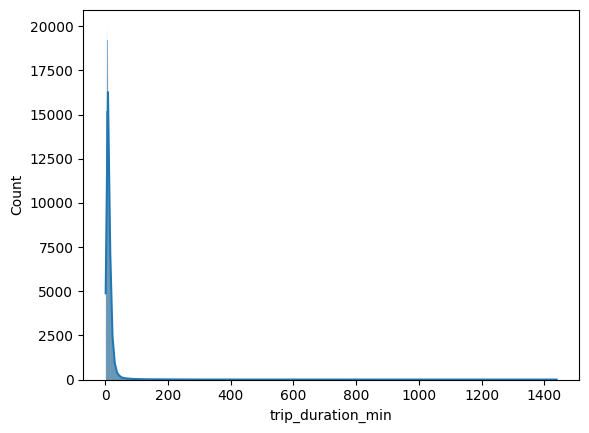

In [61]:
# Trip Duration
sns.histplot(df['trip_duration_min'],kde=True)
plt.show()

## Analysis

#The histogram illustrates the distribution of trip durations across all
#recorded rides. Most trips are concentrated within shorter durations,
 #while the frequency gradually decreases as trip duration increases,
 #indicating a positively skewed distribution. This suggests that the
 #bike-sharing service is primarily used for short-distance travel and
 # daily commuting rather than extended journeys.

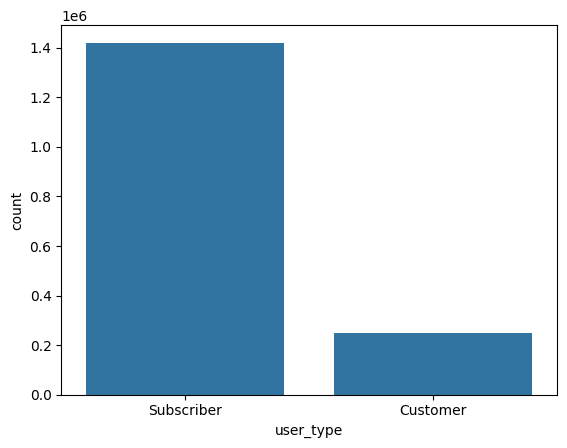

In [62]:
# User Type
sns.countplot(x='user_type',data=df)
plt.show()


## Analysis

#The count plot compares the number of rides made by Subscribers and Customers.
#The distribution highlights the relative contribution of each user category to
#the overall ridership. This comparison provides valuable insight into customer
#composition and helps evaluate the importance of subscription-based memberships
# for the bike-sharing system.\

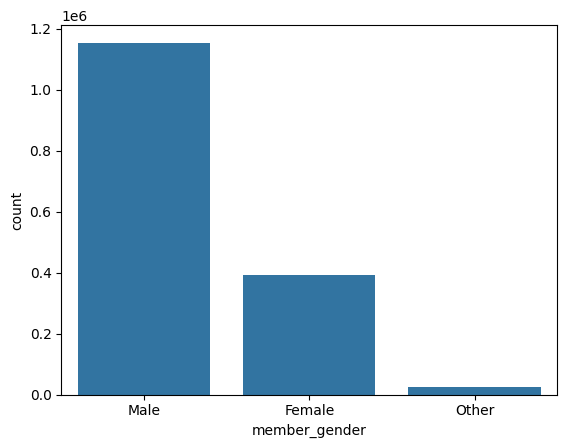

In [63]:
# Gender
sns.countplot(x='member_gender',data=df)
plt.show()

## Analysis

# This chart describes about target gender group are male, who are willing for
# bike rides

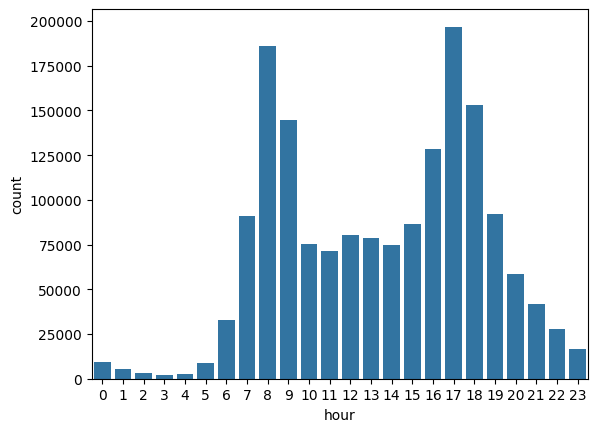

In [64]:
# Hour of Trip
sns.countplot(x='hour',data=df)
plt.show()

# Analysis

# The visualization helps identify periods of high and low activity, which are
#useful for understanding commuting patterns and customer behavior. These
#insights can assist in optimizing bike availability and operational planning
#during peak usage periods.The peak periods are Early morning hours and late
# evening hours.

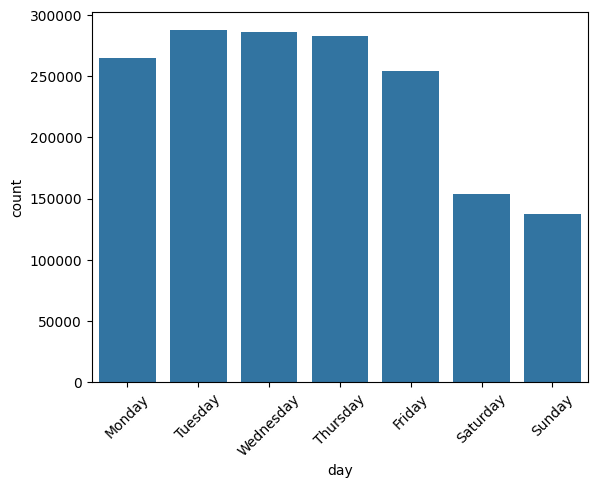

In [65]:
order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

sns.countplot(x='day',
              order=order,
              data=df)

plt.xticks(rotation=45)
plt.show()


# Analysis

#This visualization compares ride frequency across the days of the week.
#It highlights customer activity is high during weekdays than weekends.

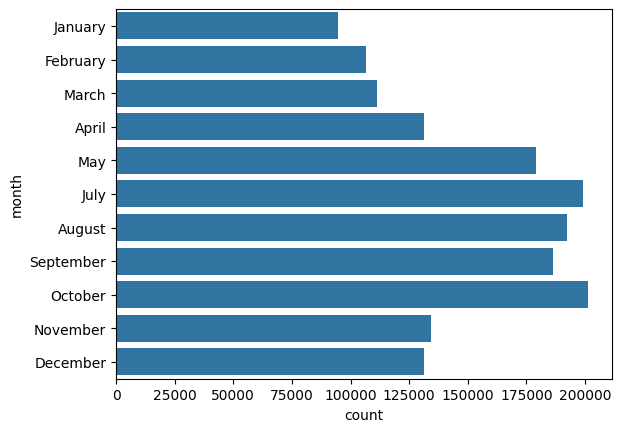

In [66]:
# Month
sns.countplot(y='month',data=df)
plt.show()

# Analysis

#The monthly count plot illustrates how ride frequency changes over different
#months of the year. Variations in monthly demand may reflect seasonal
#conditions, weather influences, or changes in customer travel behavior.

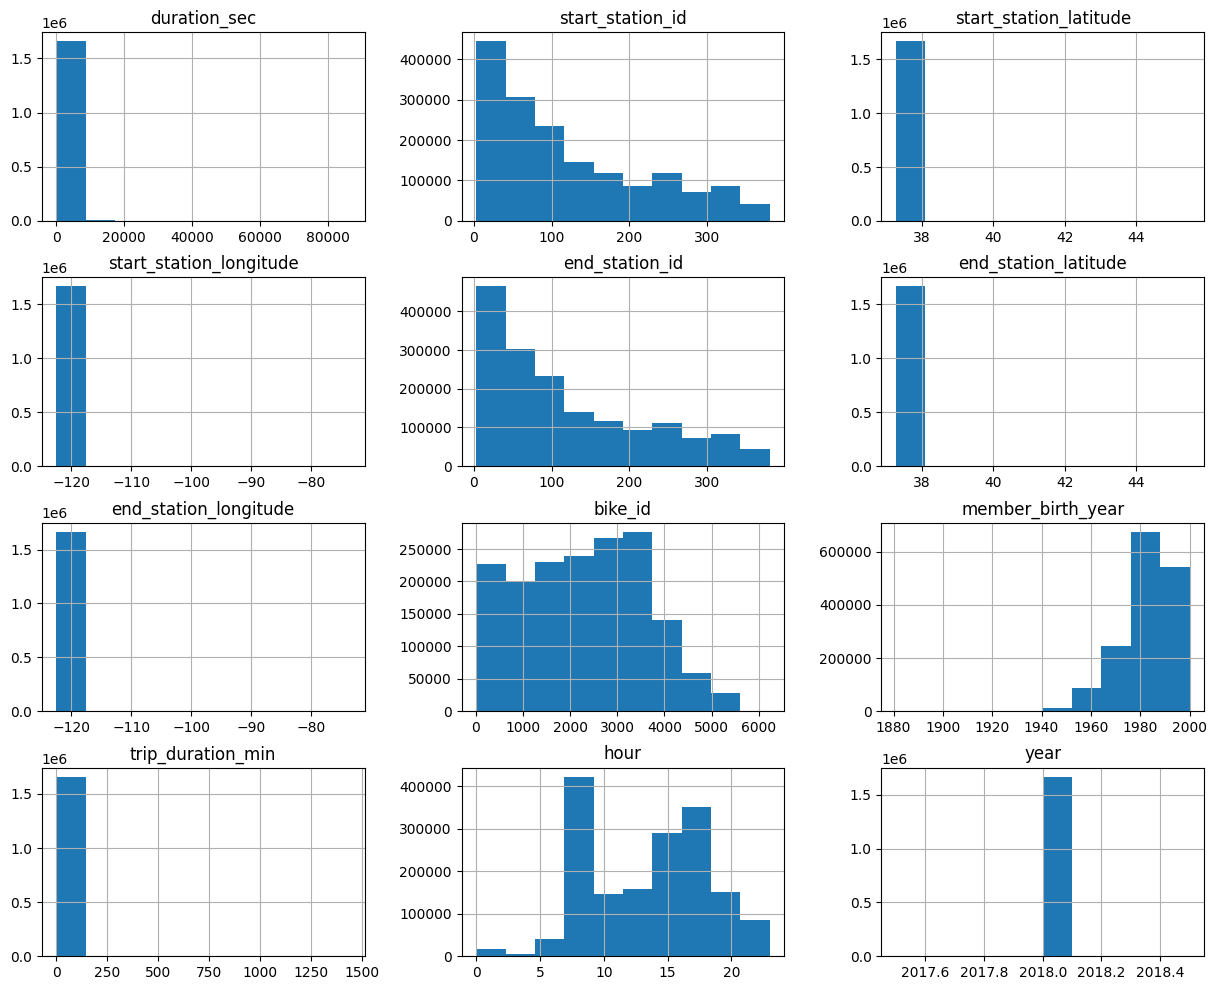

In [67]:
# Numerical Columns
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols].hist(figsize=(15,12))
plt.show()

## Analysis

#The collection of histograms provides an overview of the distribution of all
#numerical variables in the dataset. Examining these distributions helps
#identify skewness, variability, and unusual values within individual features.

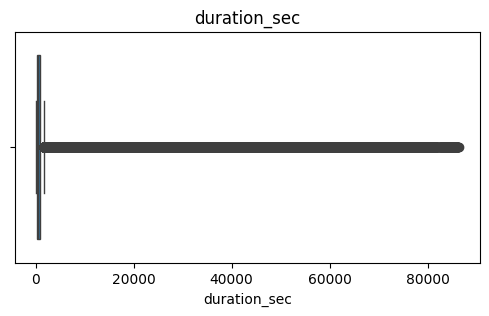

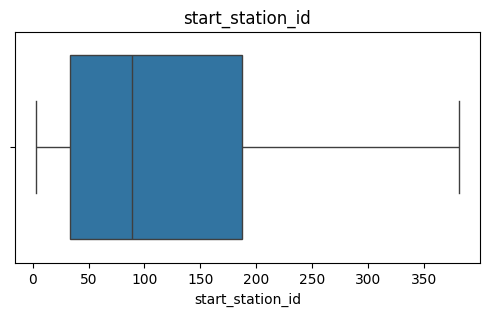

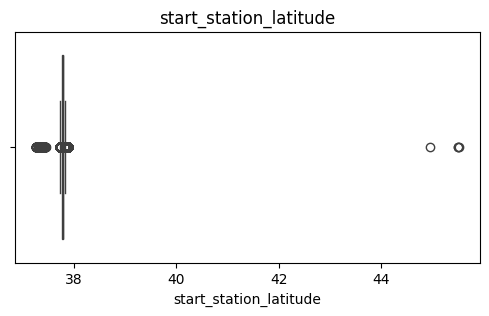

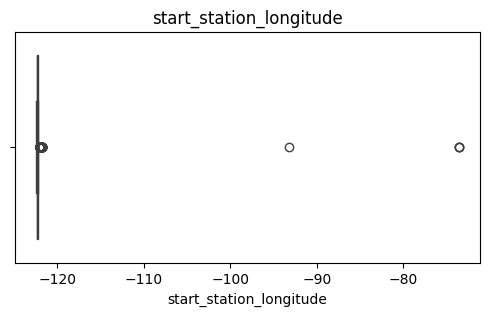

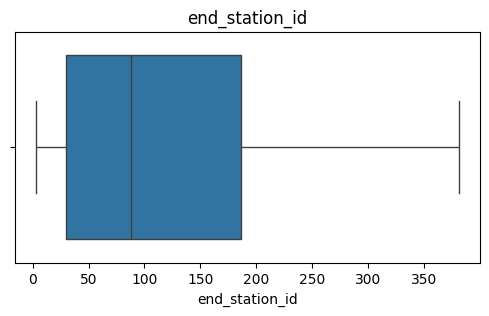

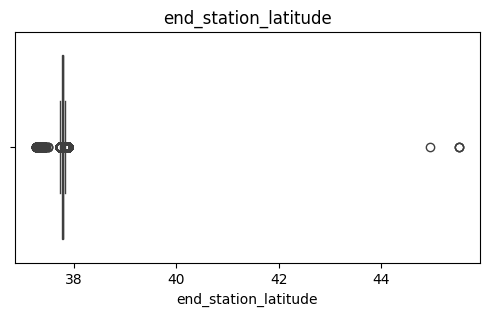

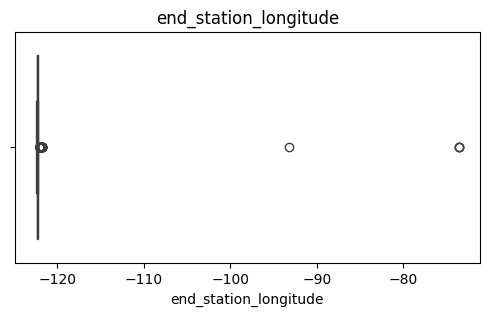

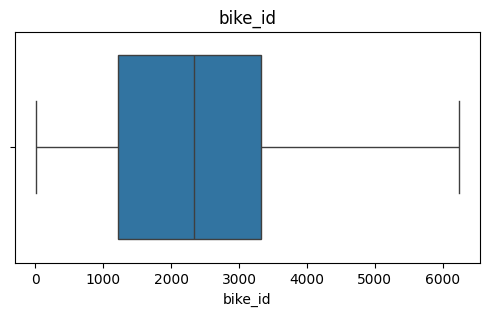

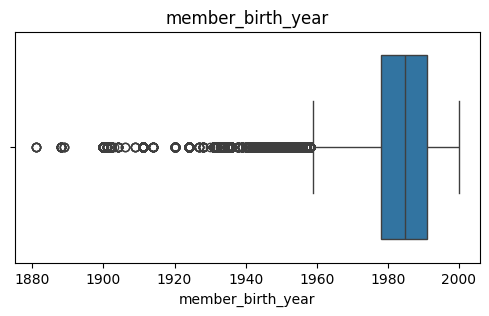

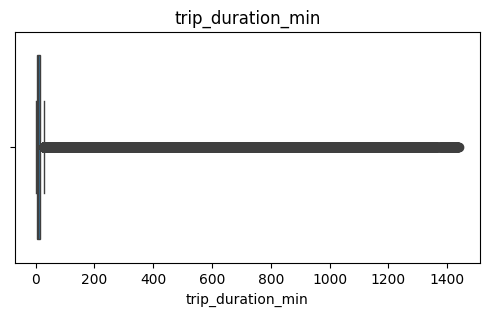

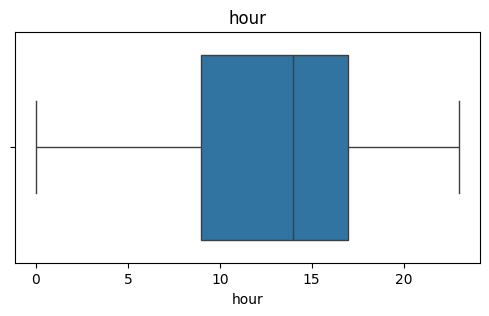

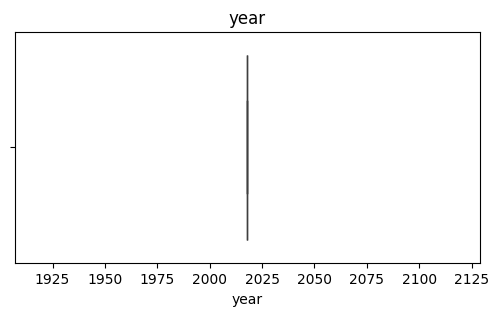

In [68]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

    # Analysis

# The box plots summarize the spread of numerical variables and highlight the
#presence of potential outliers. They display the median, interquartile range,
#and extreme observations, enabling a clear assessment of data variability.

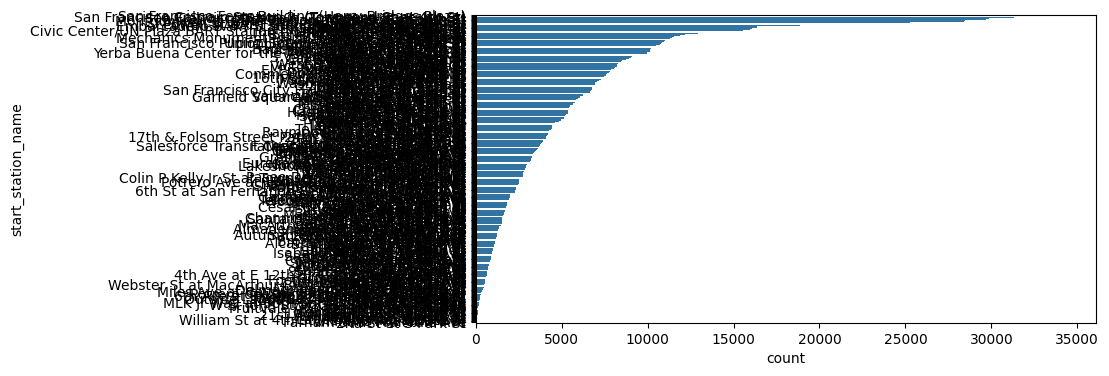

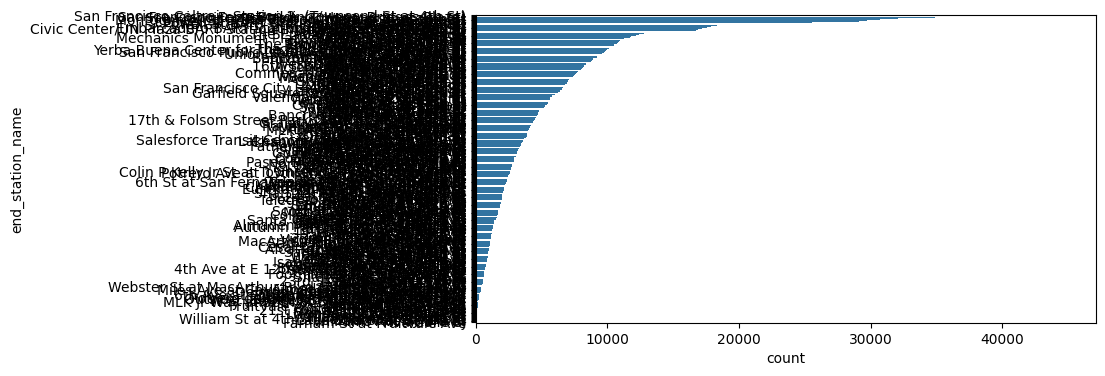

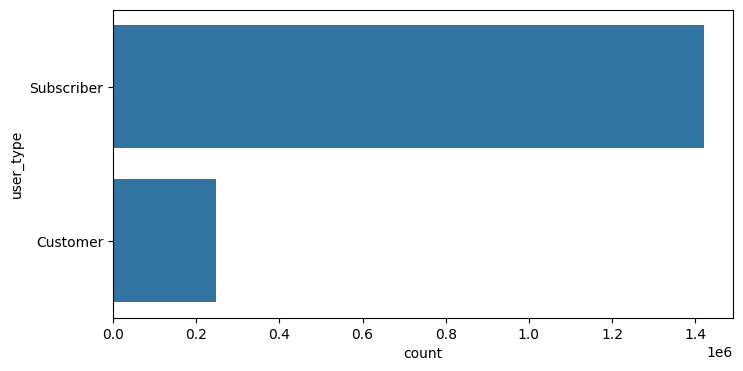

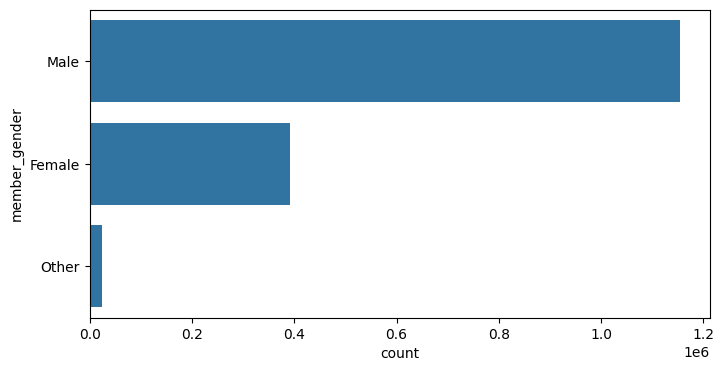

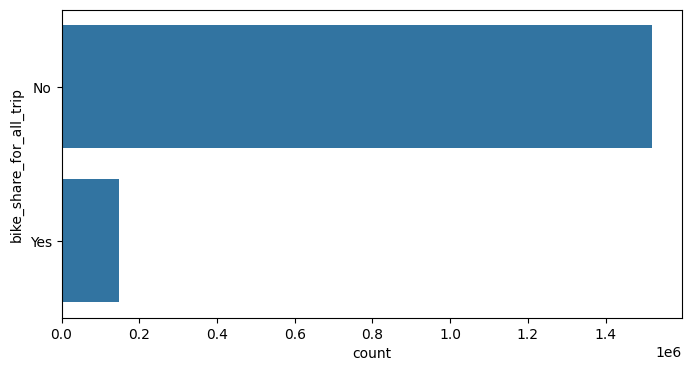

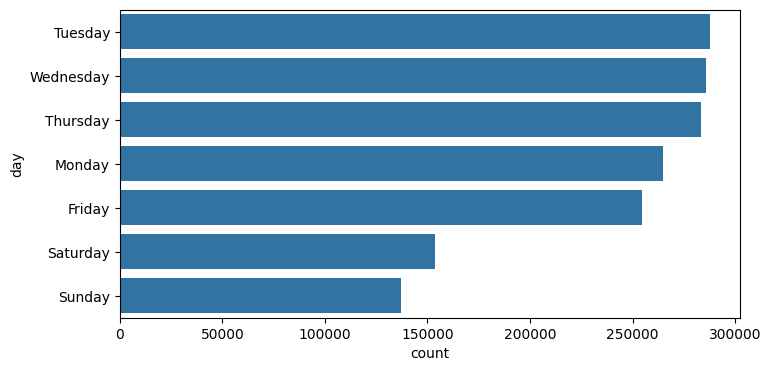

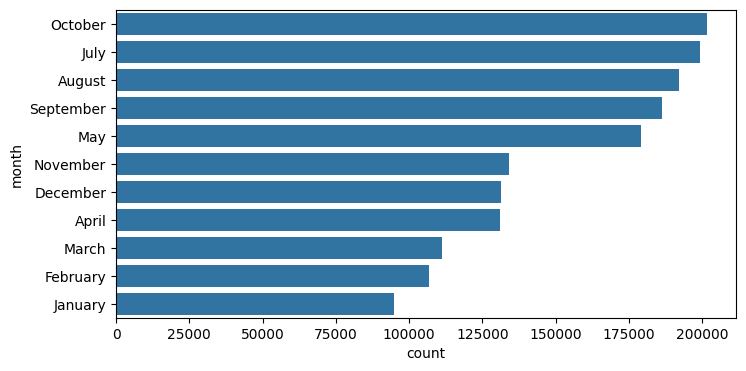

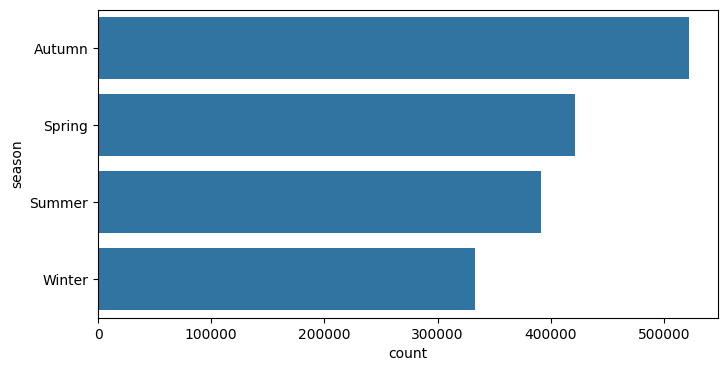

In [69]:
# Categorical Analysis
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(y=df[col], order=df[col].value_counts().index)
    plt.show()

# Analysis

#The count plots display the frequency distribution of each categorical variable
# in the dataset. They allow easy comparison among categories and help identify
#the most frequently occurring values. This analysis contributes to a better
#understanding of customer characteristics and operational features represented
#in the dataset.

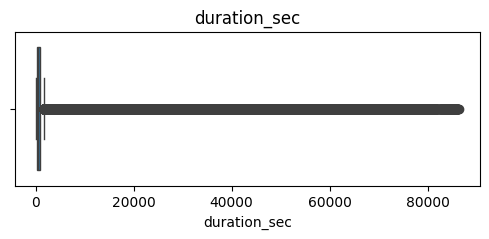

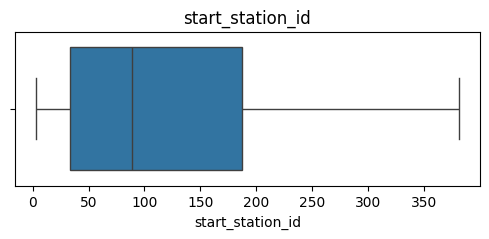

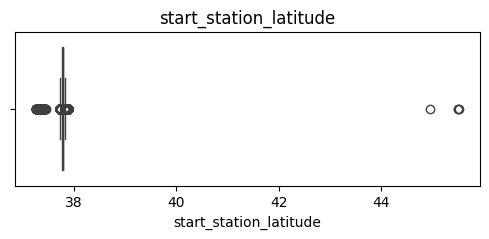

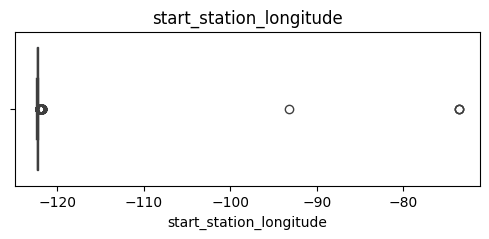

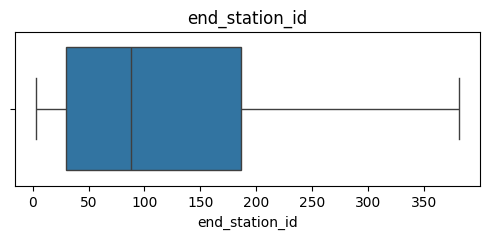

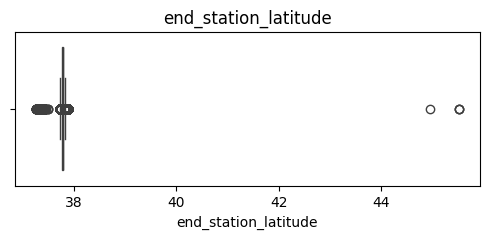

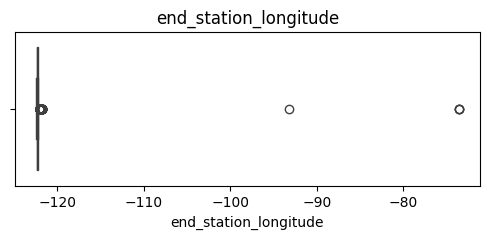

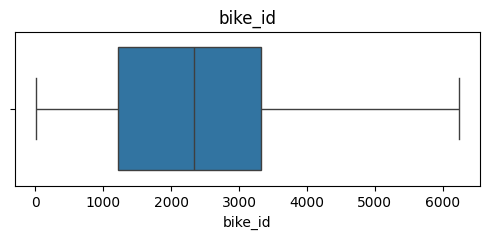

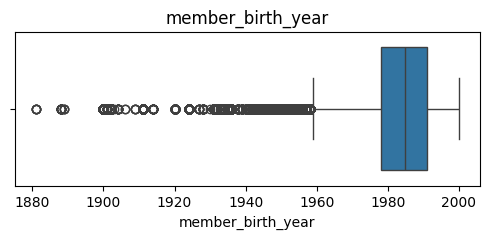

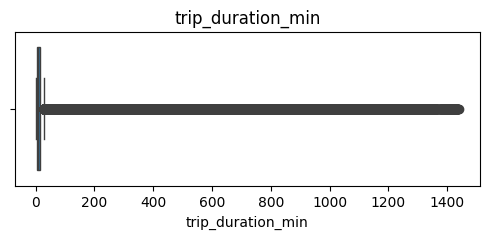

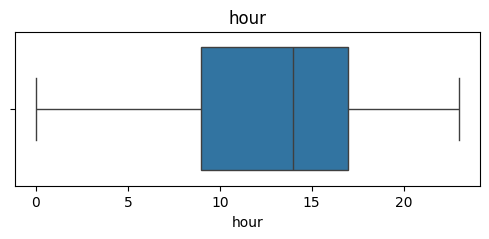

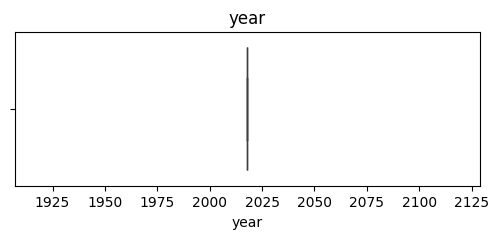

In [39]:
# Outlier Detection
num_cols=df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

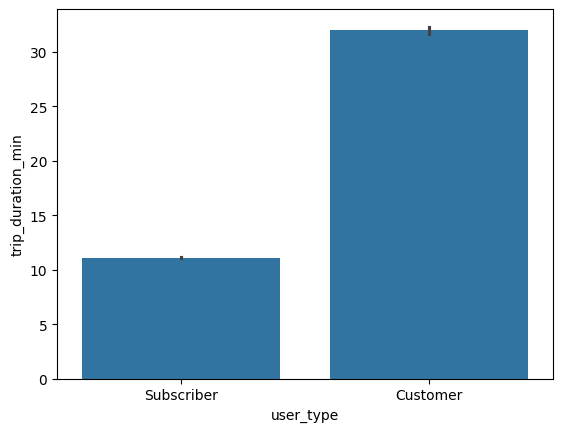

In [70]:
## Bivariate Analysis
## Trip Duration vs User Type
sns.barplot(x='user_type', y='trip_duration_min', data=df)
plt.show()

# Analysis

#The box plot compares the distribution of trip durations between different user
# categories. It highlights variations in median trip duration, overall spread,
# and the presence of extreme values within each group. This comparison helps
# evaluate whether membership type influences riding behavior and trip length.

In [41]:
#Average Trip Duration
avg_trip = df['trip_duration_min'].mean()
print(f"Average Trip Duration: {avg_trip:.2f} minutes")

Average Trip Duration: 14.19 minutes


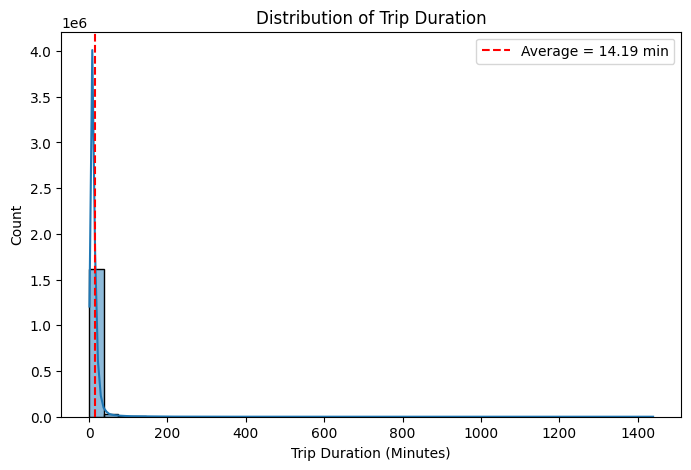

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['trip_duration_min'], bins=40, kde=True)
plt.axvline(avg_trip, color='red', linestyle='--', label=f'Average = {avg_trip:.2f} min')
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration (Minutes)')
plt.legend()
plt.show()

# Analysis

#The bar chart presents the average trip duration for each gender category. It
#provides a clear comparison of riding patterns among different user groups and
# helps identify any noticeable differences in average travel time.

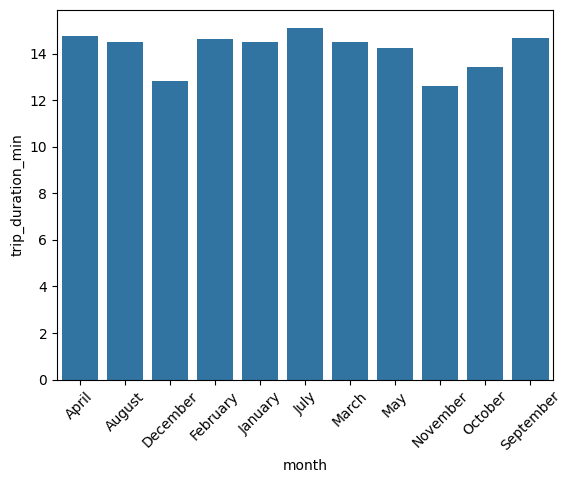

In [43]:
# Trip Duration by Month
monthly=df.groupby('month')['trip_duration_min'].mean().reset_index()

sns.barplot(data=monthly,
            x='month',
            y='trip_duration_min')

plt.xticks(rotation=45)
plt.show()

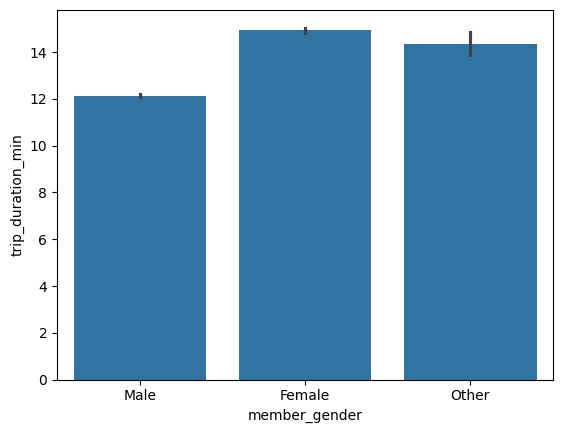

In [72]:
# Average Duration by Gender
sns.barplot(x='member_gender',
            y='trip_duration_min',
            data=df)
plt.show()

# Analysis

# The bar chart presents the average trip duration for each gender category.
#It provides a clear comparison of riding patterns among different user groups
# and helps identify any noticeable differences in average travel time.

<Axes: xlabel='user_type', ylabel='trip_duration_min'>

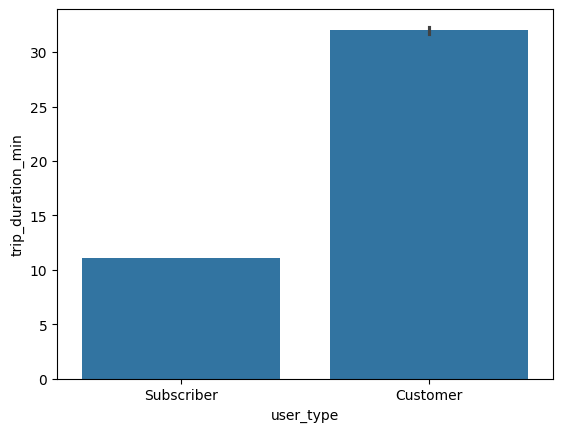

In [45]:
# Subscriber vs Customer
sns.barplot(data=df,
            x='user_type',
            y='trip_duration_min')

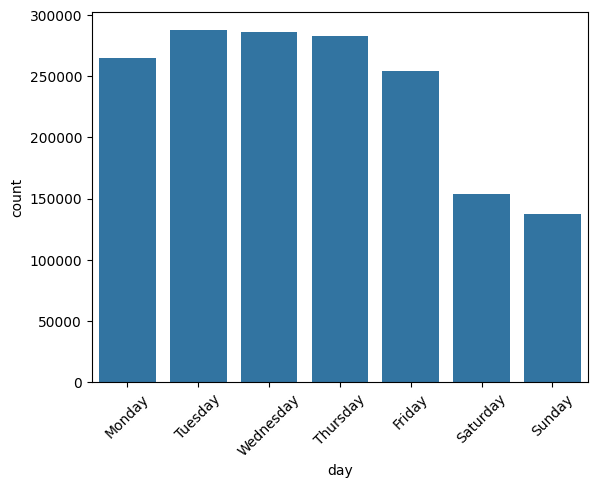

In [73]:
# Trips per day
sns.countplot(x='day',
              data=df,
              order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])

plt.xticks(rotation=45)
plt.show()

# Analysis

# The visualization compares the number of trips recorded on each day of the
#week. It highlights variations in customer activity throughout the week and
#helps identify periods of higher and lower demand. These findings tells about
# more demand for bikes during weekdays tuesdat, wednesday, thursday.

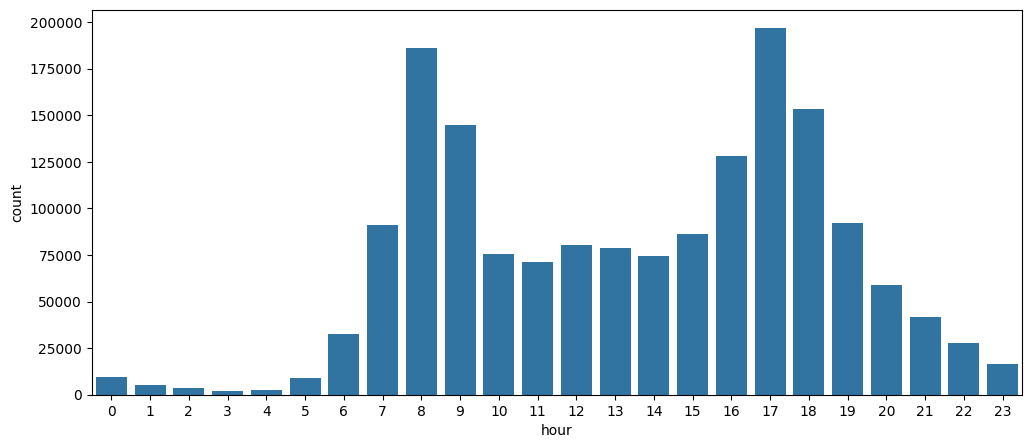

In [74]:
# Trips per Hour
plt.figure(figsize=(12,5))

sns.countplot(x='hour', data=df)

plt.show()

#Analysis

#The hourly distribution illustrates how bike usage changes throughout the day.
#It demonstrates peak demand periods are early mornings and late evenings which
#we need to increase more bikes

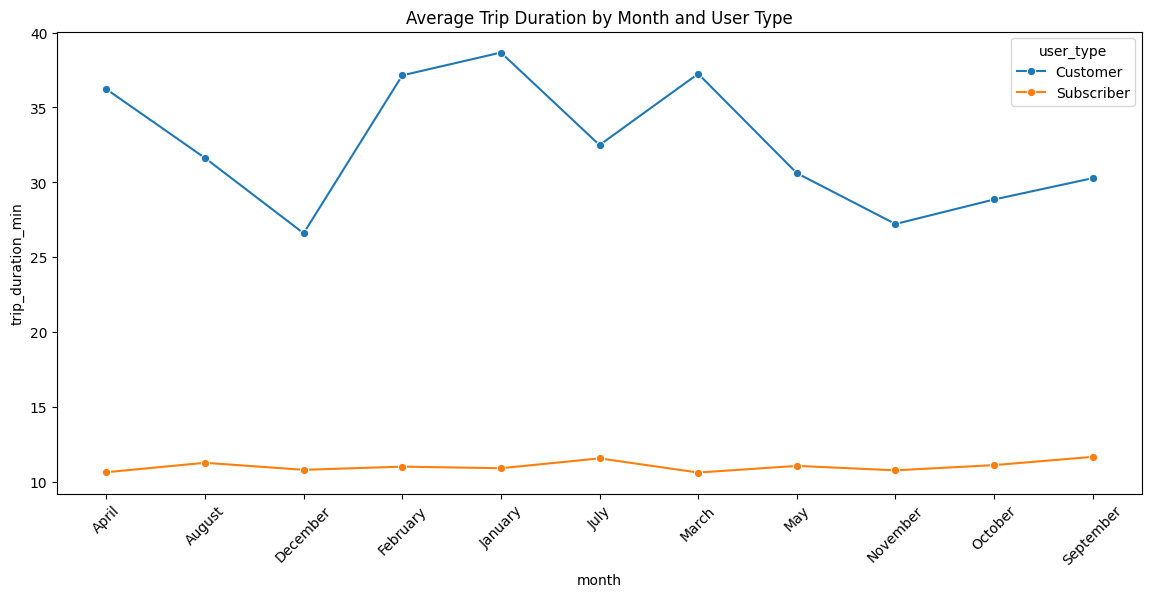

In [78]:
plt.figure(figsize=(14,6))

sns.lineplot(data=monthly_user,
             x='month',
             y='trip_duration_min',
             hue='user_type',
             marker='o')

plt.xticks(rotation=45)
plt.title("Average Trip Duration by Month and User Type")
plt.show()

<Axes: xlabel='member_gender', ylabel='trip_duration_min'>

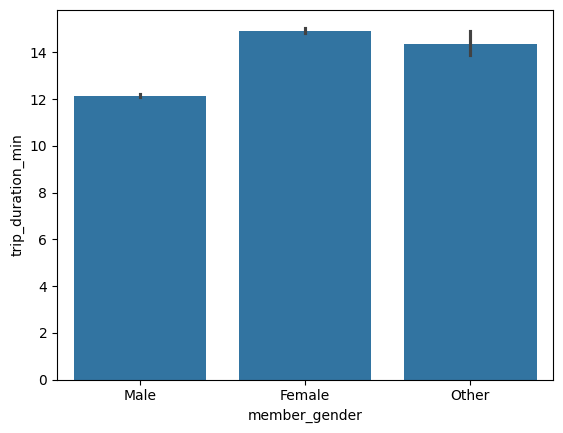

In [76]:
# Gender vs Duration
sns.barplot(data=df,
            x='member_gender',
            y='trip_duration_min')

# Analysis

#The box plot compares the distribution of trip durations across gender
#categories. It highlights differences in median values, variability, and
#the presence of outliers. This comparison contributes to a better understanding
# of demographic variations in riding behavior.

In [50]:
df.columns

Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip',
       'trip_duration_min', 'hour', 'day', 'month', 'year'],
      dtype='object')

<Axes: xlabel='member_birth_year', ylabel='trip_duration_min'>

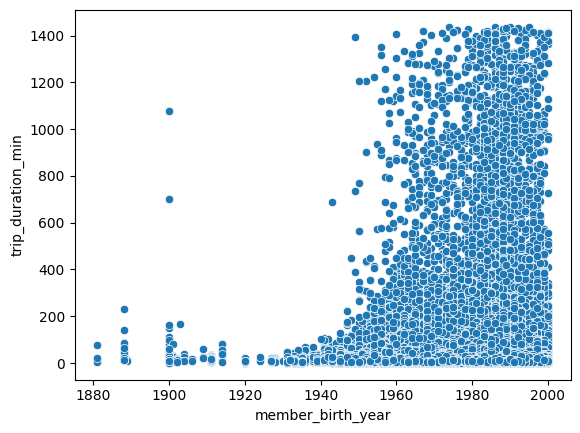

In [77]:
# Age vs Duration
sns.scatterplot(data=df,
                x='member_birth_year',
                y='trip_duration_min')

# Analysis

# The scatter plot illustrates the relationship between rider age and trip
#duration. It helps identify whether any noticeable trend exists between these
#two variables while also revealing the spread of observations and potential
#outliers. This analysis supports demographic profiling of users are with
#age group of 25 to 45.

Multivariate Analysis

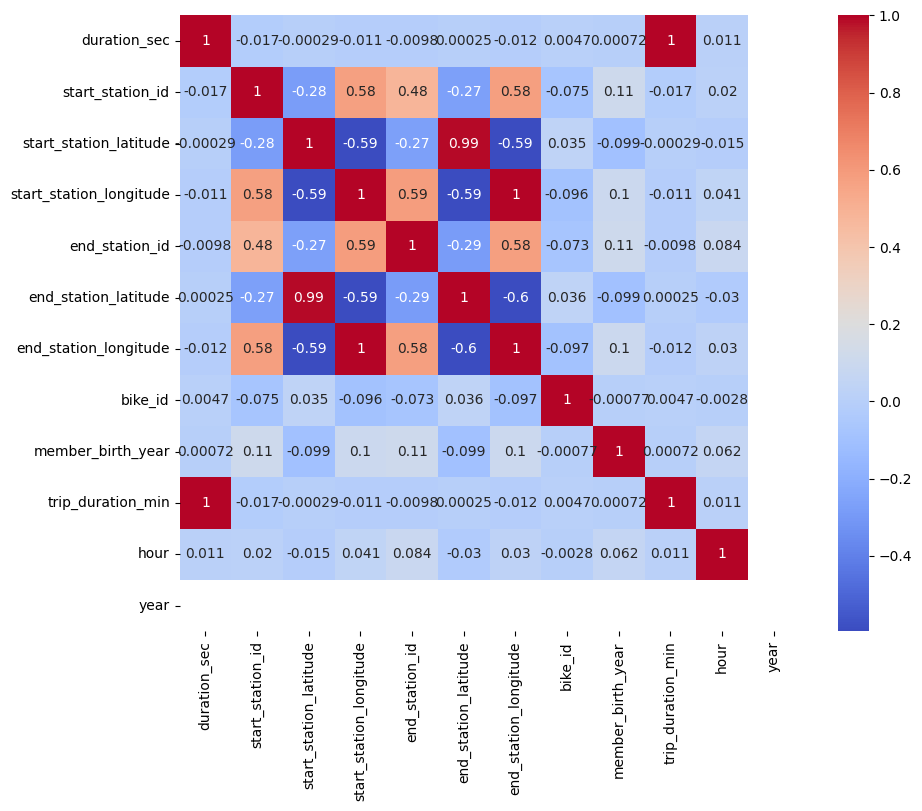

In [52]:
# Correlation Analysis
plt.figure(figsize=(10,8))

sns.heatmap(df[num_cols].corr(),
            annot=True,
            cmap='coolwarm')

plt.show()

In [53]:
## Seasons
def season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Autumn'

df['season'] = df['start_time'].dt.month.apply(season)

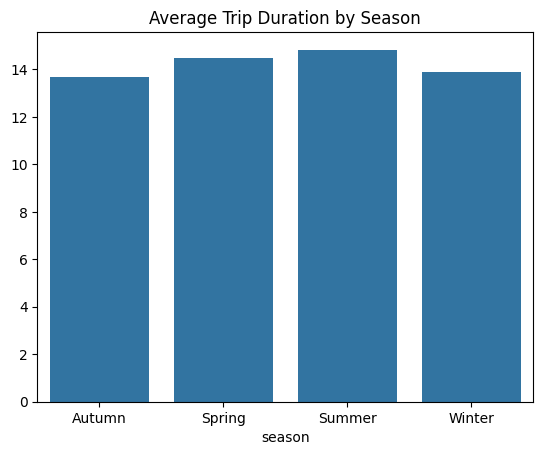

In [54]:
season_duration = df.groupby('season')['trip_duration_min'].mean()

sns.barplot(x=season_duration.index,
            y=season_duration.values)

plt.title("Average Trip Duration by Season")
plt.show()

## Trip duration varies across months/seasons. Some months show longer
## average rides, suggesting seasonal changes in riding behavior.

In [55]:
## Q3: Does the above depend on whether a user is a Subscriber or Customer?
## Multivariate Analysis
## Average duration by User Type
user_duration = df.groupby('user_type')['trip_duration_min'].mean()

print(user_duration)

user_type
Customer      31.992883
Subscriber    11.090275
Name: trip_duration_min, dtype: float64


# Business Insights

The Exploratory Data Analysis of the Ford GoBike dataset provided several valuable insights into customer travel behavior and bike-sharing usage patterns.

1. The majority of bike trips are of relatively short duration, indicating that the service is primarily used for short-distance travel and daily commuting.

2. Ride demand varies across different hours of the day, with clear peak periods that reflect regular commuting schedules. This suggests that customer demand is influenced by daily travel routines.

3. Monthly and seasonal analysis indicates that trip duration and ride frequency change over time, demonstrating that external factors such as weather conditions and seasonal trends influence bike usage.

4. The comparison between Subscribers and Customers shows noticeable differences in riding behavior, suggesting that membership type plays an important role in trip frequency and duration.

5. Customer demographic analysis provides useful information about the distribution of riders across different age groups and gender categories, helping to better understand the primary user base.

6. Outlier analysis identified a small number of unusually long trips, while most rides remained within a typical duration range. These observations should be considered during future operational analysis.

7. The correlation analysis indicates that most numerical variables have weak to moderate relationships, suggesting that customer behavior is influenced by multiple factors rather than a single variable.

Overall, the analysis demonstrates that customer behavior is shaped by a combination of temporal, demographic, and membership-related factors, providing meaningful insights for operational planning and strategic decision-making.



# Recommendations
1. Increase bike availability and station capacity during peak commuting hours to meet higher customer demand and reduce service shortages.

2. Monitor seasonal and monthly demand patterns to optimize bike redistribution, maintenance schedules, and staffing requirements throughout the year.

3. Develop promotional campaigns aimed at converting casual Customers into Subscribers by highlighting the benefits of long-term membership.

4. Improve operational planning at stations with consistently high usage to reduce waiting times and enhance customer satisfaction.

5. Use customer demographic insights to design targeted marketing strategies that encourage wider adoption of the bike-sharing service among different user groups.

6. Regularly monitor unusually long trips and data outliers to ensure data quality and identify potential operational issues or exceptional usage patterns.

7. Utilize the findings from this analysis as a foundation for advanced analytics, including demand forecasting, customer segmentation, and predictive modeling, to support long-term business growth.


# Conclusion

The primary objective of this project was to perform Exploratory Data Analysis (EDA) on the Ford GoBike dataset to understand customer travel behavior, identify usage patterns, and generate meaningful business insights. The analysis focused on answering key business questions related to average trip duration, the impact of monthly and seasonal variations on ride behavior, and differences between Subscribers and Customers.

To achieve these objectives, the dataset was systematically prepared through data cleaning, handling missing values, removing duplicate records, and transforming relevant variables into appropriate formats. Additional features were created to support time-based analysis, enabling a comprehensive examination of ride duration, customer demographics, ride frequency, and temporal trends. Various statistical techniques and visualizations were applied to explore both individual variables and relationships among multiple variables.

The findings indicate that bike usage is influenced by a combination of temporal factors, customer demographics, and membership type. Variations in ride patterns across different months and time periods demonstrate the importance of considering seasonal demand when planning operations. Likewise, the comparison between Subscribers and Customers highlights meaningful differences in user behavior that can support customer retention and membership strategies.

Overall, this project demonstrates the value of Exploratory Data Analysis in transforming raw operational data into practical business knowledge. The insights generated can assist stakeholders in making informed decisions regarding resource allocation, station management, service optimization, and customer engagement. Furthermore, this study establishes a strong analytical foundation for future work involving predictive analytics, demand forecasting, and customer segmentation, ultimately contributing to a more efficient, data-driven, and customer-focused bike-sharing system.

